In [1]:
import os
import sys

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(project_root)

c:\Users\POTHURAJU\logistics_delivery_analytics


In [2]:
from src.data_loader import load_data
from src.data_cleaner import clean_data
from src.business_analysis import *
from src.visualization import *


In [3]:
import os
print(os.getcwd())

c:\Users\POTHURAJU\logistics_delivery_analytics\notebooks


In [4]:
import os
import sys

sys.path.append(r"C:\Users\POTHURAJU\logistics_delivery_analytics")

In [5]:
from src.data_loader import load_data

In [6]:
df = load_data("../data/raw/logistics_data.csv")

In [7]:
clean_df["return_flag"].unique()

NameError: name 'clean_df' is not defined

In [ ]:
clean_df["damage_flag"].unique()

<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

# Section 1: Business Understanding


# Section 2: Import Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_data
from src.data_cleaner import clean_data

# Section 3: Load Data


In [8]:
df = load_data(r"C:\Users\POTHURAJU\logistics_delivery_analytics\data\raw\logistics_data.csv")
df.head()

,order_id,customer_id,order_date,warehouse,origin_city,destination_city,distance_km,product_category,quantity,weight_kg,...,shipping_cost,fuel_cost,warehouse_processing_hours,dispatch_date,expected_delivery_date,actual_delivery_date,delivery_status,customer_rating,damage_flag,return_flag
0,ORD101253,CUST12780,2025-03-12,Bengaluru,Bengaluru,Chennai,451.7,Home & Kitchen,7,5.51,...,2044.56,381.66,8.36,2025-03-14,2025-03-19,2025-03-24,Delayed,3.0,No,No
1,ORD102838,CUST11842,2025-12-02,Delhi,Delhi,Surat,592.8,Automotive,1,1.05,...,2582.70,385.02,10.33,2025-12-05,2025-12-12,2025-12-12,Delivered,4.0,No,No
2,ORD103457,CUST10940,2025-04-21,Pune,Pune,Nagpur,191.9,Clothing,3,9.09,...,817.23,185.83,8.88,2025-04-23,2025-04-28,2025-04-28,Delivered,5.0,No,No
3,ORD100061,CUST10263,2025-02-21,Pune,Pune,Coimbatore,376.4,Clothing,7,1.34,...,1713.22,386.35,10.18,2025-02-24,2025-03-02,2025-03-04,Delayed,3.0,No,No
4,ORD103947,CUST12467,2025-08-22,Mumbai,Mumbai,Delhi,895.3,Sports,5,3.95,...,3980.06,990.42,11.17,2025-08-24,2025-08-30,2025-08-30,Delivered,4.0,No,No


# Data Understanding

In [9]:
df.shape

(5000, 22)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   order_id                    5000 non-null   str    
 1   customer_id                 5000 non-null   str    
 2   order_date                  5000 non-null   str    
 3   warehouse                   5000 non-null   str    
 4   origin_city                 5000 non-null   str    
 5   destination_city            4960 non-null   str    
 6   distance_km                 5000 non-null   float64
 7   product_category            5000 non-null   str    
 8   quantity                    5000 non-null   int64  
 9   weight_kg                   5000 non-null   float64
 10  shipping_mode               5000 non-null   str    
 11  delivery_partner            5000 non-null   str    
 12  shipping_cost               4950 non-null   float64
 13  fuel_cost                   4950 non-null   

In [11]:
df.describe()

,distance_km,quantity,weight_kg,shipping_cost,fuel_cost,warehouse_processing_hours,customer_rating
count,5000.000000,5000.000000,5000.000000,4950.000000,4950.000000,4941.000000,4911.000000
mean,411.098620,3.967000,5.528694,2286.791669,373.230737,8.391716,4.124822
std,260.537306,2.009955,3.921885,1682.276034,246.607318,2.306332,0.711340
min,-25.000000,0.000000,0.200000,-100.000000,20.000000,2.000000,2.000000
25%,221.775000,2.000000,2.700000,1141.012500,194.930000,6.810000,4.000000
50%,354.350000,4.000000,4.640000,1808.200000,319.115000,8.380000,4.000000
75%,541.800000,6.000000,7.422500,2906.355000,497.037500,10.020000,5.000000
max,1800.000000,7.000000,34.090000,16275.330000,1755.710000,15.650000,5.000000


# Section 5: Data Quality Analysis


In [12]:
df.isnull().sum()

order_id                       0
customer_id                    0
order_date                     0
warehouse                      0
origin_city                    0
destination_city              40
distance_km                    0
product_category               0
quantity                       0
weight_kg                      0
shipping_mode                  0
delivery_partner               0
shipping_cost                 50
fuel_cost                     50
warehouse_processing_hours    59
dispatch_date                  0
expected_delivery_date         0
actual_delivery_date           0
delivery_status                0
customer_rating               89
damage_flag                    0
return_flag                    0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(25)

# Section 6: Data Cleaning


In [14]:
clean_df = clean_data(df)

In [15]:
clean_df.head()

,order_id,customer_id,order_date,warehouse,origin_city,destination_city,distance_km,product_category,quantity,weight_kg,...,actual_delivery_date,delivery_status,customer_rating,damage_flag,return_flag,delivery_days,delay_days,cost_per_km,total_logistics_cost,on_time_flag
0,ORD101253,CUST12780,2025-03-12,Bengaluru,Bengaluru,Chennai,451.7,Home & Kitchen,7,5.51,...,2025-03-24,Delayed,3.0,0,0,10,5,4.526367,2426.22,0
1,ORD102838,CUST11842,2025-12-02,Delhi,Delhi,Surat,592.8,Automotive,1,1.05,...,2025-12-12,Delivered,4.0,0,0,7,0,4.356781,2967.72,1
2,ORD103457,CUST10940,2025-04-21,Pune,Pune,Nagpur,191.9,Clothing,3,9.09,...,2025-04-28,Delivered,5.0,0,0,5,0,4.258624,1003.06,1
3,ORD100061,CUST10263,2025-02-21,Pune,Pune,Coimbatore,376.4,Clothing,7,1.34,...,2025-03-04,Delayed,3.0,0,0,8,2,4.551594,2099.57,0
4,ORD103947,CUST12467,2025-08-22,Mumbai,Mumbai,Delhi,895.3,Sports,5,3.95,...,2025-08-30,Delivered,4.0,0,0,6,0,4.445504,4970.48,1


# Section 7: Derived Columns


In [16]:
clean_df = clean_data(df)

clean_df[
    [
        "delivery_days",
        "delay_days",
        "cost_per_km",
        "total_logistics_cost",
        "on_time_flag"
    ]
].head()

,delivery_days,delay_days,cost_per_km,total_logistics_cost,on_time_flag
0,10,5,4.526367,2426.22,0
1,7,0,4.356781,2967.72,1
2,5,0,4.258624,1003.06,1
3,8,2,4.551594,2099.57,0
4,6,0,4.445504,4970.48,1


# Section 8: EDA

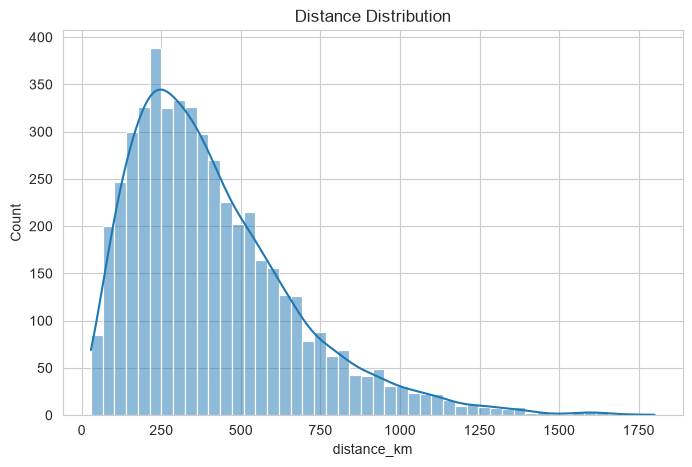

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(clean_df["distance_km"], kde=True)
plt.title("Distance Distribution")
plt.show()

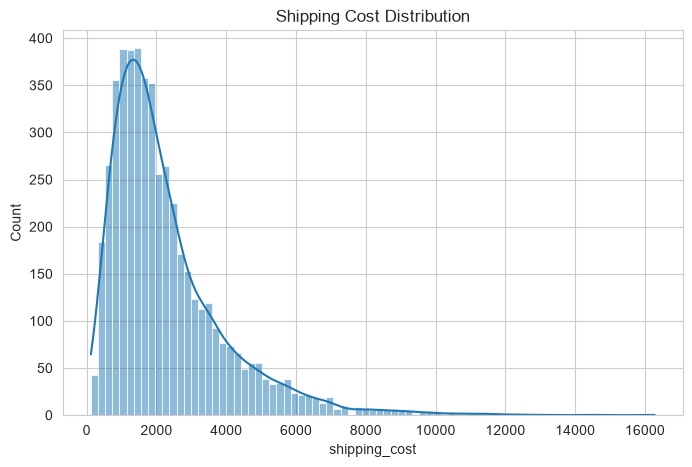

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(clean_df["shipping_cost"], kde=True)
plt.title("Shipping Cost Distribution")
plt.show()

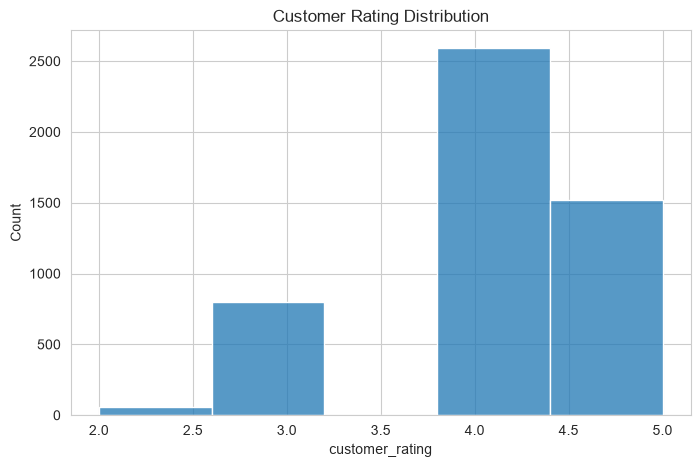

In [19]:
# Customer Rating Distribution


plt.figure(figsize=(8,5))
sns.histplot(clean_df["customer_rating"], bins=5)
plt.title("Customer Rating Distribution")
plt.show()

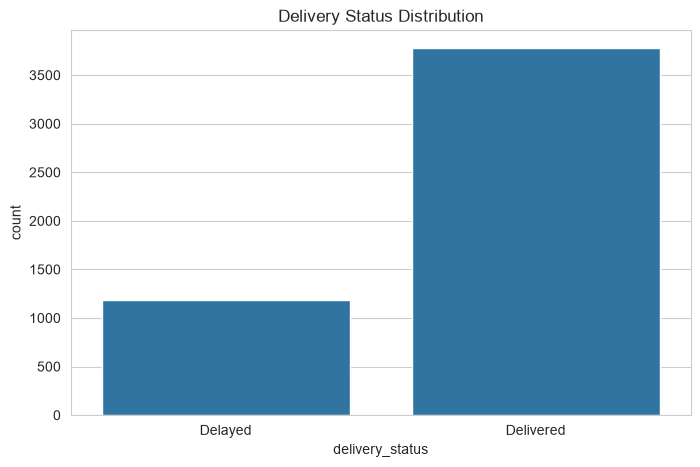

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(data=clean_df, x="delivery_status")
plt.title("Delivery Status Distribution")
plt.show()

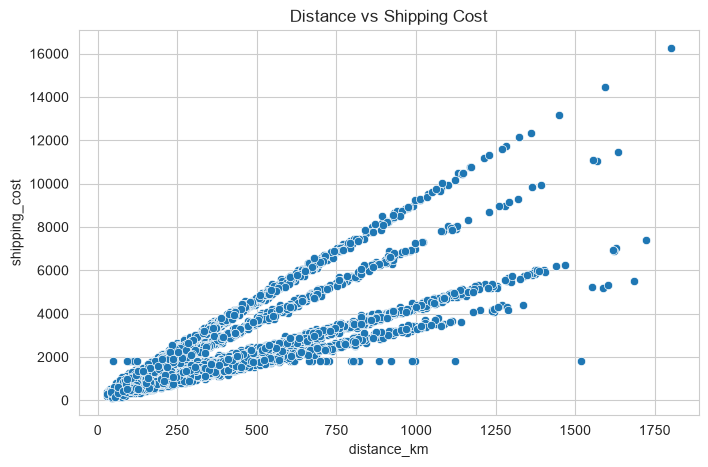

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=clean_df,
    x="distance_km",
    y="shipping_cost"
)
plt.title("Distance vs Shipping Cost")
plt.show()

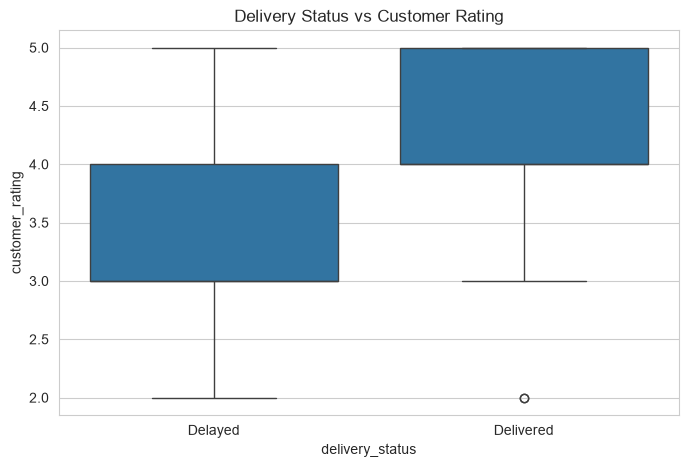

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=clean_df,
    x="delivery_status",
    y="customer_rating"
)
plt.title("Delivery Status vs Customer Rating")
plt.show()

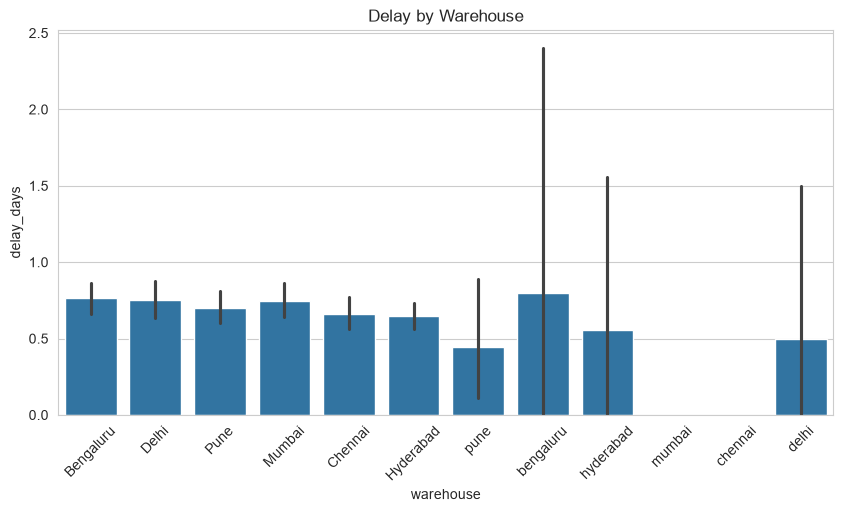

In [23]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=clean_df,
    x="warehouse",
    y="delay_days"
)
plt.xticks(rotation=45)
plt.title("Delay by Warehouse")
plt.show()

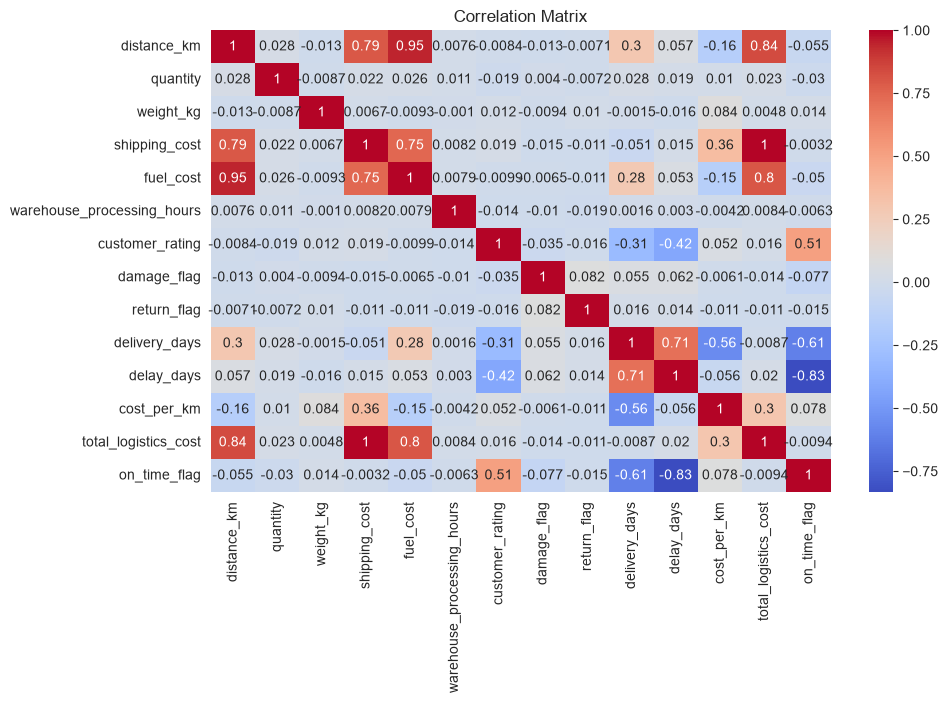

In [24]:
plt.figure(figsize=(10,6))

sns.heatmap(
    clean_df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

# Section 9: KPI Analysis

In [25]:
from src.business_analysis import *

In [26]:
print("Total Orders:", calculate_total_orders(clean_df))

print("Total Delivered:", calculate_total_delivered(clean_df))

print("Total Delayed:", calculate_total_delayed(clean_df))

print("On Time Percentage:", calculate_on_time_percentage(clean_df))

print("Average Delivery Days:",
      calculate_average_delivery_days(clean_df))

print("Average Delay Days:",
      calculate_average_delay_days(clean_df))

Total Orders: 4963
Total Delivered: 3775
Total Delayed: 1188
On Time Percentage: 76.06
Average Delivery Days: 5.63
Average Delay Days: 2.95


Cost KPIs

In [27]:
print("Total Shipping Cost:",
      calculate_total_shipping_cost(clean_df))

print("Average Shipping Cost:",
      calculate_average_shipping_cost(clean_df))

print("Total Fuel Cost:",
      calculate_total_fuel_cost(clean_df))

print("Total Logistics Cost:",
      calculate_total_logistics_cost(clean_df))

print("Average Logistics Cost:",
      calculate_average_logistics_cost(clean_df))

print("Average Cost Per KM:",
      calculate_average_cost_per_km(clean_df))

Total Shipping Cost: 11325014.57
Average Shipping Cost: 2281.888891799315
Total Fuel Cost: 1848496.415
Total Logistics Cost: 13173510.985
Average Logistics Cost: 2654.3443451541407
Average Cost Per KM: 5.771681618775666


In [28]:
clean_df["return_flag"] = (
    clean_df["return_flag"]
    .map({
        "Yes": 1,
        "No": 0
    })
)

clean_df["damage_flag"] = (
    clean_df["damage_flag"]
    .map({
        "Yes": 1,
        "No": 0
    })
)

In [29]:
print("Average Customer Rating:",
      calculate_average_customer_rating(clean_df))

print("Return Rate:",calculate_return_rate(clean_df))

print("Damage Rate:",
      calculate_damage_rate(clean_df))

Average Customer Rating: 4.122506548458594
Return Rate: 0.0
Damage Rate: 0.0


In [30]:
clean_df[["return_flag", "damage_flag"]].dtypes

return_flag    float64
damage_flag    float64
dtype: object

In [31]:
clean_df[["return_flag", "damage_flag"]].head()

,return_flag,damage_flag
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


In [32]:
clean_df[["return_flag", "damage_flag"]].head()

clean_df[["return_flag", "damage_flag"]].dtypes

return_flag    float64
damage_flag    float64
dtype: object

In [60]:
clean_df["return_flag"].dtype

<StringDtype(na_value=nan)>

In [61]:
clean_df["return_flag"].head(10)

0    No
1    No
2    No
3    No
4    No
5    No
6    No
7    No
8    No
9    No
Name: return_flag, dtype: str

In [62]:
clean_df["return_flag"].unique()

<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

In [63]:
clean_df["damage_flag"].unique()

<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

In [64]:
clean_df["return_flag"] = pd.to_numeric(
    clean_df["return_flag"],
    errors="coerce"
)

clean_df["damage_flag"] = pd.to_numeric(
    clean_df["damage_flag"],
    errors="coerce"
)

In [65]:
print("Return Rate:",
      calculate_return_rate(clean_df))

print("Damage Rate:",
      calculate_damage_rate(clean_df))

Return Rate: nan
Damage Rate: nan


In [33]:
route_performance = analyze_route_performance(clean_df)
route_performance.head(10)

,origin_city,destination_city,shipment_count
0,Bengaluru,Ahmedabad,50
1,Bengaluru,Bengaluru,1
2,Bengaluru,Bhopal,48
3,Bengaluru,Chennai,50
4,Bengaluru,Coimbatore,57
5,Bengaluru,Delhi,55
6,Bengaluru,Hyderabad,49
7,Bengaluru,Indore,61
8,Bengaluru,Jaipur,54
9,Bengaluru,Kochi,51


In [34]:
route_cost = analyze_route_cost(clean_df)
route_cost.sort_values(
    by="total_logistics_cost",
    ascending=False
).head(10)

,origin_city,destination_city,total_logistics_cost
35,Chennai,Unknown,3944.482500
92,Mumbai,Unknown,3698.470000
4,Bengaluru,Coimbatore,3459.975702
103,Pune,Jaipur,3397.923019
99,Pune,Coimbatore,3278.655000
56,Delhi,Visakhapatnam,3266.631316
50,Delhi,Mumbai,3167.048810
110,Pune,Surat,3153.932273
23,Chennai,Coimbatore,3148.299348
108,Pune,Nagpur,3098.871154


In [35]:
route_delay = analyze_route_delays(clean_df)
route_delay.sort_values(
    by="delay_days",
    ascending=False
).head(10)

,origin_city,destination_city,delay_days
1,Bengaluru,Bengaluru,6.000000
16,Bengaluru,Unknown,2.400000
63,Hyderabad,Hyderabad,1.800000
53,Delhi,Surat,1.404762
104,Pune,Kochi,1.289474
111,Pune,Unknown,1.250000
13,Bengaluru,Nagpur,1.240000
39,Delhi,Bengaluru,1.181818
29,Chennai,Kolkata,1.166667
19,Chennai,Ahmedabad,1.148936


In [36]:
shipping_mode_usage = analyze_shipping_mode(clean_df)
shipping_mode_usage

shipping_mode
Air         903
Express     607
Rail        922
Road       2492
air           7
express       5
rail          6
road         21
dtype: int64

In [37]:
shipping_mode_cost = analyze_shipping_mode_cost(clean_df)
shipping_mode_cost.sort_values(ascending=False)

shipping_mode
air        4321.062857
Air        4143.018743
Express    3461.021540
express    3311.280000
road       2245.488095
Road       2215.875947
Rail       1853.496264
rail       1113.246667
Name: total_logistics_cost, dtype: float64

In [38]:
shipping_mode_delay = analyze_shipping_mode_delays(clean_df)
shipping_mode_delay.sort_values(ascending=False)

shipping_mode
express    2.000000
air        1.285714
rail       0.833333
Rail       0.812364
Road       0.755217
road       0.571429
Air        0.569214
Express    0.523888
Name: delay_days, dtype: float64

In [39]:
partner_volume = analyze_delivery_partner(clean_df)
partner_volume.sort_values(ascending=False)

delivery_partner
Ecom Express    844
Shadowfax       834
XpressBees      833
Delhivery       826
DTDC            801
Blue Dart       786
blue dart         9
xpressbees        9
ecom express      6
dtdc              6
shadowfax         6
delhivery         3
dtype: int64

In [40]:
partner_cost = analyze_partner_cost(clean_df)
partner_cost.sort_values(ascending=False)

delivery_partner
ecom express    4368.788333
xpressbees      3037.043333
delhivery       3010.423333
Ecom Express    2744.627678
DTDC            2743.022079
Shadowfax       2726.212770
Blue Dart       2658.999358
blue dart       2588.053333
XpressBees      2543.498625
Delhivery       2502.278232
shadowfax       2181.543333
dtdc            1945.715000
Name: total_logistics_cost, dtype: float64

In [41]:
partner_delay = analyze_partner_delays(clean_df)
partner_delay.sort_values(ascending=False)


delivery_partner
blue dart       1.111111
dtdc            1.000000
DTDC            0.832709
XpressBees      0.782713
Ecom Express    0.772512
Delhivery       0.679177
Shadowfax       0.610312
Blue Dart       0.557252
delhivery       0.333333
ecom express    0.333333
shadowfax       0.166667
xpressbees      0.000000
Name: delay_days, dtype: float64

In [42]:
partner_damage = analyze_partner_damage_rate(clean_df)
partner_damage.sort_values(ascending=False)

delivery_partner
Blue Dart      NaN
DTDC           NaN
Delhivery      NaN
Ecom Express   NaN
Shadowfax      NaN
XpressBees     NaN
blue dart      NaN
delhivery      NaN
dtdc           NaN
ecom express   NaN
shadowfax      NaN
xpressbees     NaN
Name: damage_flag, dtype: float64



# Section 10: Business Analysis


In [43]:
from src.visualization import *

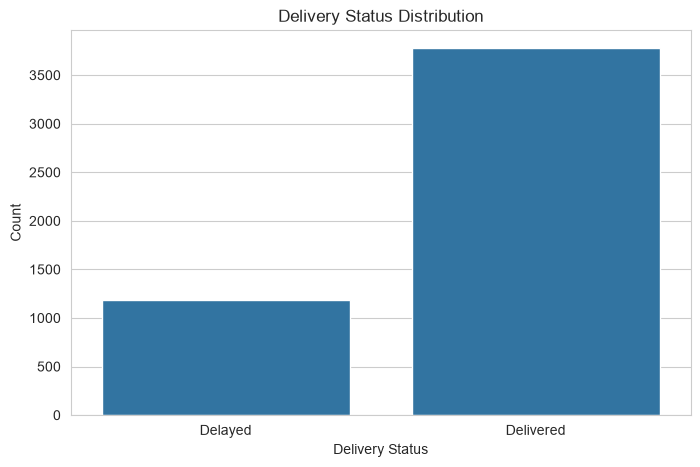

In [44]:
plot_delivery_status(clean_df)

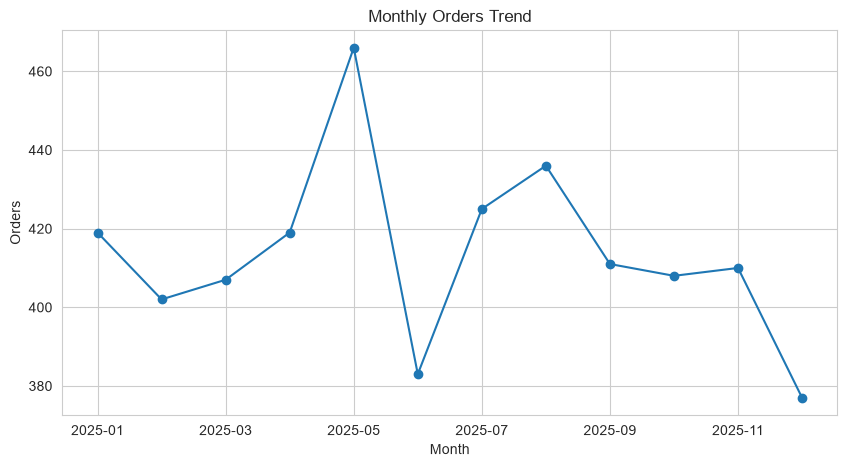

In [45]:
plot_monthly_orders(clean_df)

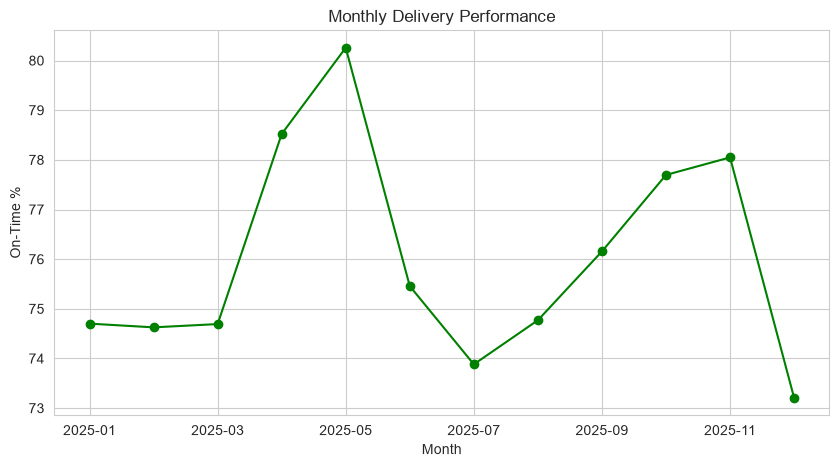

In [46]:
plot_monthly_delivery_performance(clean_df)

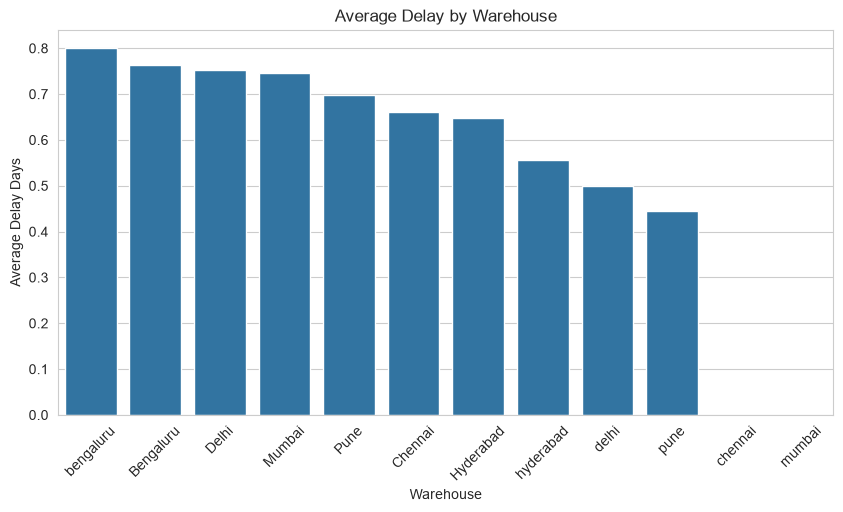

In [47]:
plot_delay_by_warehouse(clean_df)

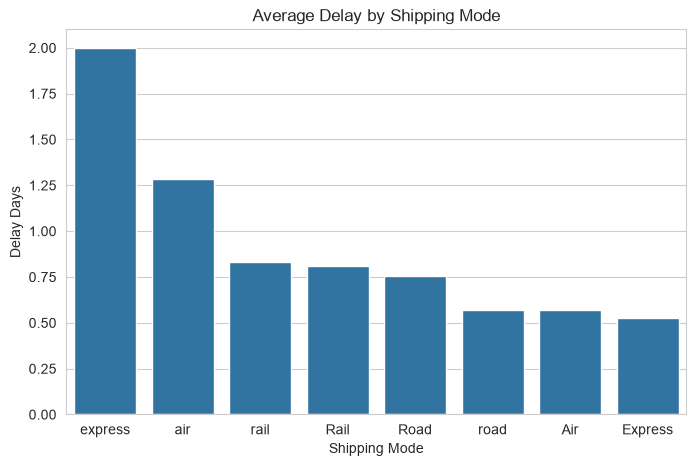

In [48]:
plot_delay_by_shipping_mode(clean_df)

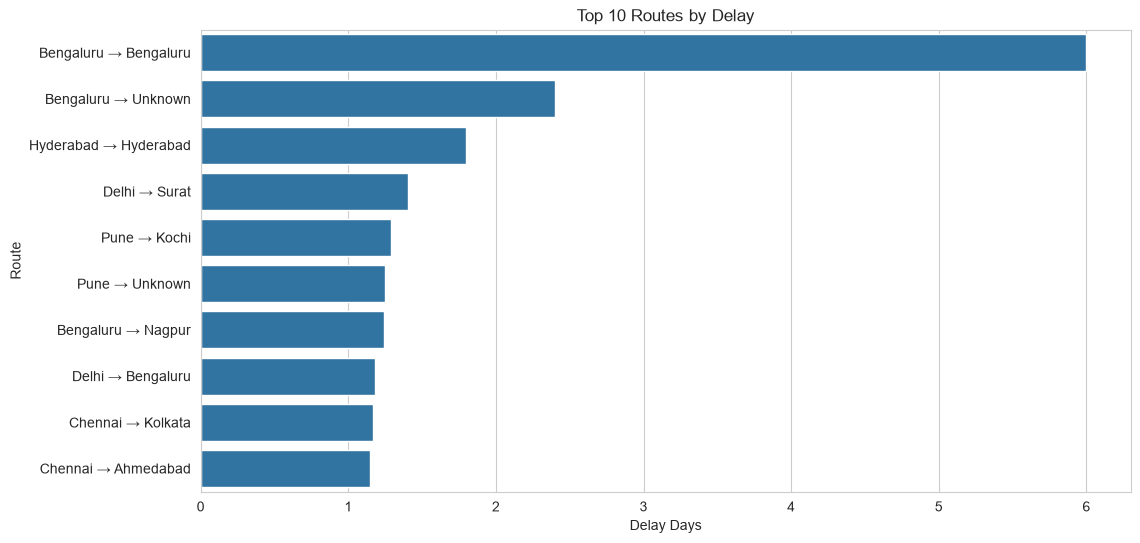

In [49]:
plot_delay_by_route(clean_df)

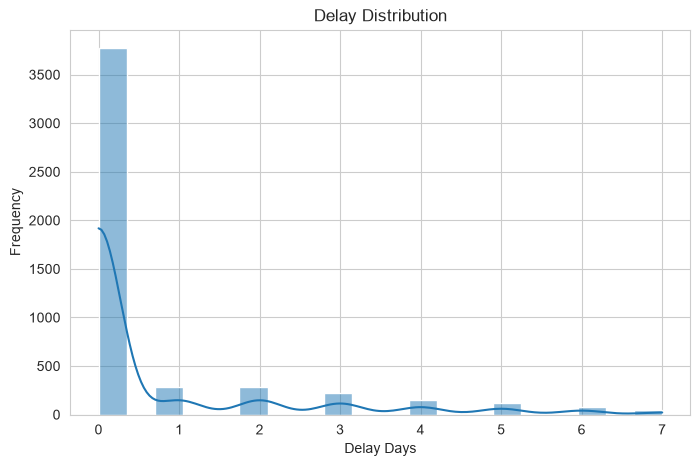

In [50]:
plot_delay_distribution(clean_df)

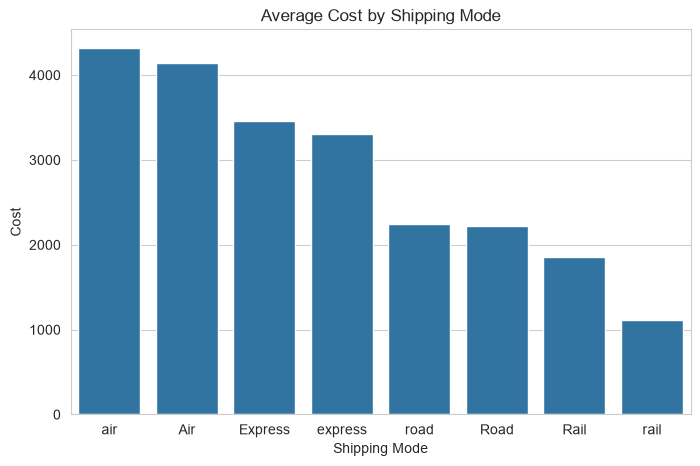

In [51]:
plot_cost_by_shipping_mode(clean_df)

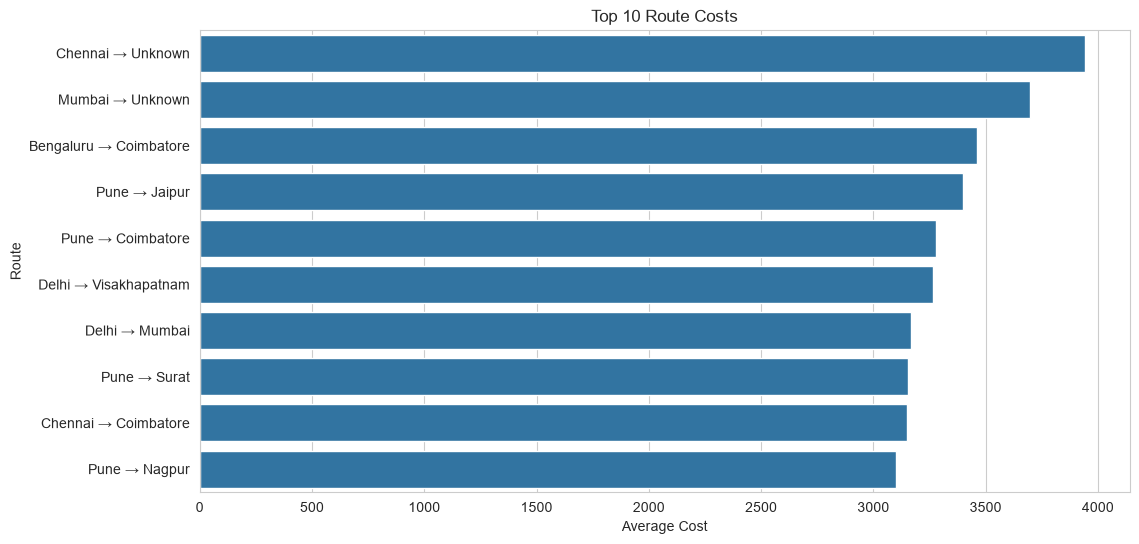

In [52]:
plot_cost_by_route(clean_df)

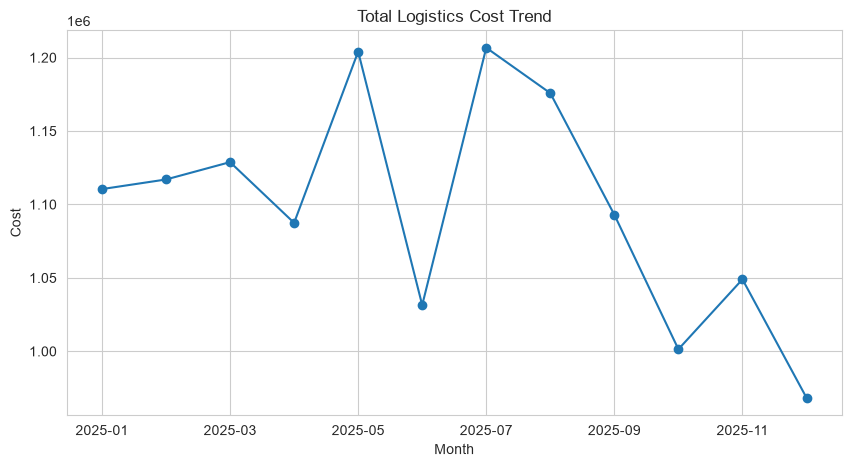

In [53]:
plot_cost_trend(clean_df)

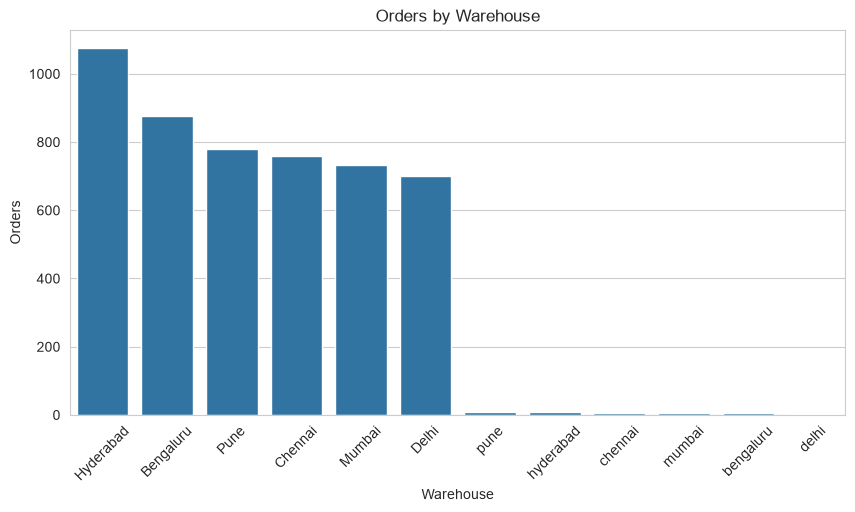

In [54]:
plot_orders_by_warehouse(clean_df)

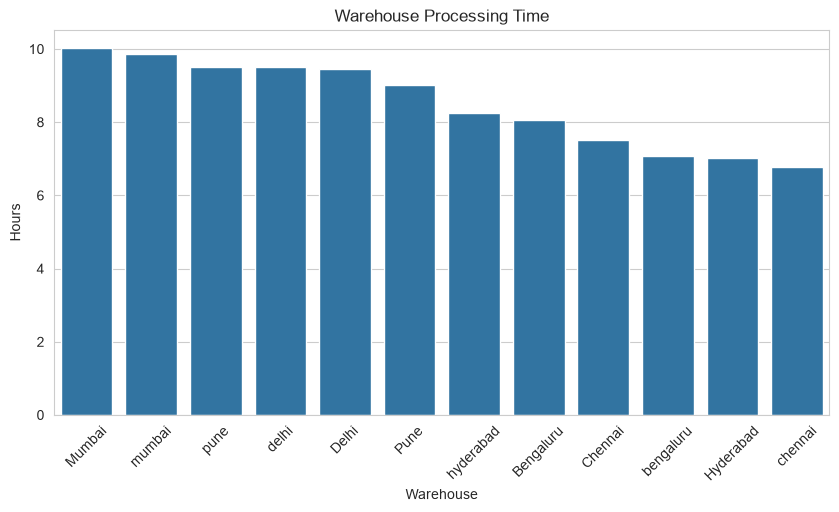

In [55]:
plot_processing_time_by_warehouse(clean_df)

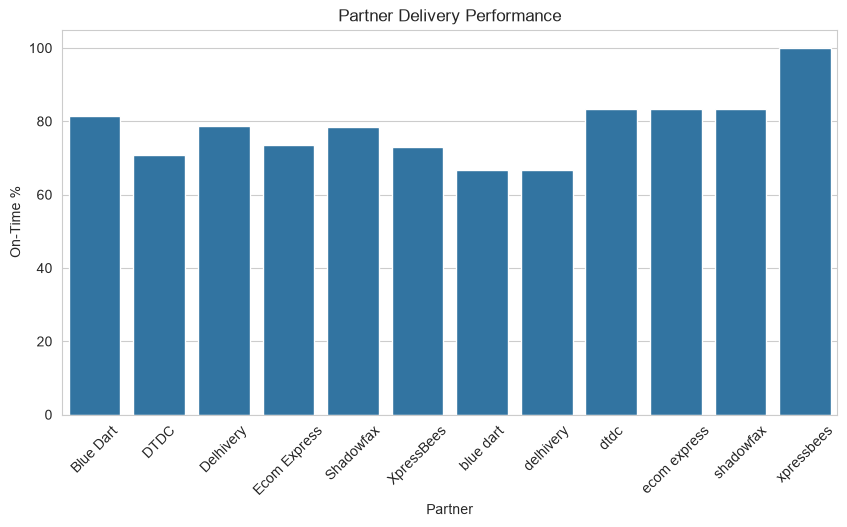

In [56]:
plot_partner_delivery_performance(clean_df)

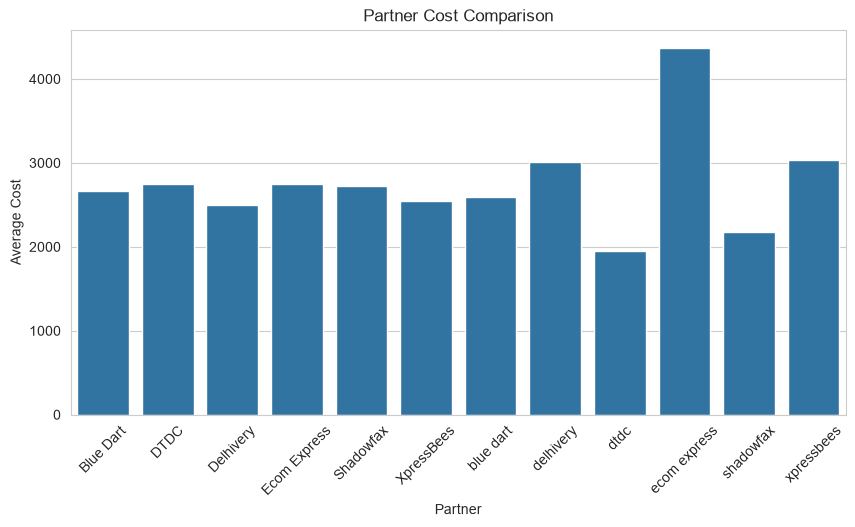

In [57]:
plot_partner_cost(clean_df)

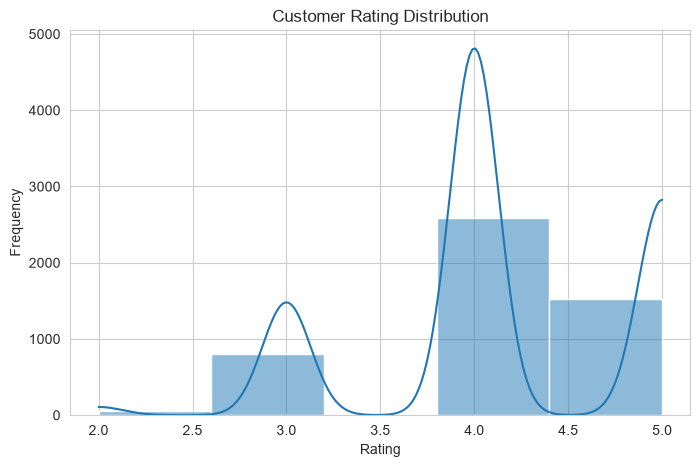

In [58]:
plot_customer_rating_distribution(clean_df)

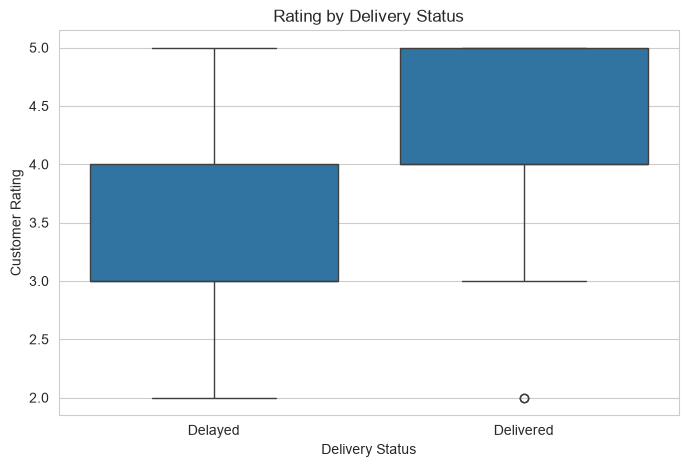

In [59]:
plot_rating_by_delivery_status(clean_df)

# Business Insights

1. Delivery delays are concentrated in selected warehouses.

2. Certain logistics routes incur significantly higher costs.

3. Transportation modes exhibit different cost and delay characteristics.

4. Delivery partner performance varies with respect to cost, delay and shipment quality.

5. Customer ratings tend to be influenced by delivery outcomes.

6. Logistics cost is strongly related to distance travelled.

# Section 13: Recommendations

# Recommendations

1. Investigate warehouses with the highest delay percentages.

2. Optimise expensive delivery routes through improved route planning.

3. Establish KPI monitoring for all delivery partners.

4. Reduce warehouse processing bottlenecks.

5. Promote efficient shipping modes where feasible.

6. Monitor damage and return rates continuously.

7. Introduce monthly logistics performance reviews.

8. Use dashboard-based monitoring for management reporting.

# Section 14: Final Conclusion

# Final Conclusion

The Logistics Delivery Performance and Cost Analytics project successfully transformed raw logistics data into business-ready information.

The project involved data loading, validation, cleaning, feature engineering, KPI calculation, statistical analysis, visualisation and business analysis.

Key business metrics such as delivery performance, delay rates, logistics costs, warehouse efficiency and partner performance were analysed.

The analysis identified operational improvement opportunities and provided practical recommendations to improve delivery performance, reduce logistics costs and enhance customer service.

The final Streamlit dashboard allows business users to interactively monitor logistics operations and support data-driven decision-making.